# BinWaves North Carolina Satellite Correction - NC-SC (Propagation)

**In this notebook**: 
<br><br>
Here is where the construction of the library of pre-run cases for all the monochromatic wave systems is made.
<br><br>
Steps:
- Generates wave conditions for all given frequencies and directions.
- Generates SWAN cases and runs them.
- Extracts SWAN cases and saves output.
- Plots the library for all the cases and some larger example ones.

## Generate computational bathymetry

In [31]:
# # Convert GEBCO to BinWaves format
# from utils.convert_bathy import convert_gebco_to_BinWaves
# input_file = 'raw_data/bathy/gebco_2024_n37.5763_s31.9852_w-79.3978_e-73.0076.nc'
# output_file = 'common_inputs/North_Carolina_utm18.nc'
# convert_gebco_to_BinWaves(input_file, output_file, input_crs="EPSG:4326", output_crs="EPSG:32618", rename_coords=True)

In [1]:
import xarray as xr
bathy = -(
    xr.open_dataset("common_inputs/North_Carolina_utm18.nc")
    .rename({"cx": "lon", "cy": "lat"})
    # .isel(lon=slice(0, None, 15), lat=slice(0, None, 15))  # This gives 500m resolution
    .transpose("lat", "lon")
    .sortby("lat", ascending=False)
    .elevation
)
bathy


<xarray.DataArray 'elevation' (lat: 1504, lon: 1443)> Size: 17MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(1504, 1443))
Coordinates:
  * lon      (lon) float64 12kB 8.474e+04 8.516e+04 ... 6.874e+05 6.878e+05
  * lat      (lat) float64 12kB 4.168e+06 4.167e+06 ... 3.539e+06 3.539e+06
    crs      int64 8B ...
Attributes:
    standard_name:       height_above_mean_sea_level
    long_name:           Elevation relative to sea level
    units:               m
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_uom_urn:         SDN:P06::ULAA
    sdn_uom_name:        Metres

In [33]:
# from utils.plotting import plot_selected_bathy

# plot_selected_bathy(bathy=bathy)

In [34]:
# from bluemath_tk.topo_bathy.swan_grid import generate_grid_parameters

# fixed_parameters = generate_grid_parameters(bathy_data=bathy, alpc=-40)
# fixed_parameters

In [2]:
fixed_parameters_swan = {
    'xpc': 287634.73,    # UTM Easting of origin (meters)
    'ypc': 3676471.67,   # UTM Northing of origin (meters)
    'alpc': 40,          # Rotation angle (degrees)
    'xlenc': 450000,     # Grid length in x (meters)
    'ylenc': 200000,     # Grid length in y (meters)
    'mxc': 799,         # Number of mesh points in x (minus 1)
    'myc': 399,          # Number of mesh points in y (minus 1)
}
fixed_parameters_swan

{'xpc': 287634.73,
 'ypc': 3676471.67,
 'alpc': 40,
 'xlenc': 450000,
 'ylenc': 200000,
 'mxc': 799,
 'myc': 399}

In [36]:
# from bluemath_tk.topo_bathy.swan_grid import generate_grid_parameters

# fixed_parameters = generate_grid_parameters(bathy_data=bathy, alpc=-40)
# fixed_parameters

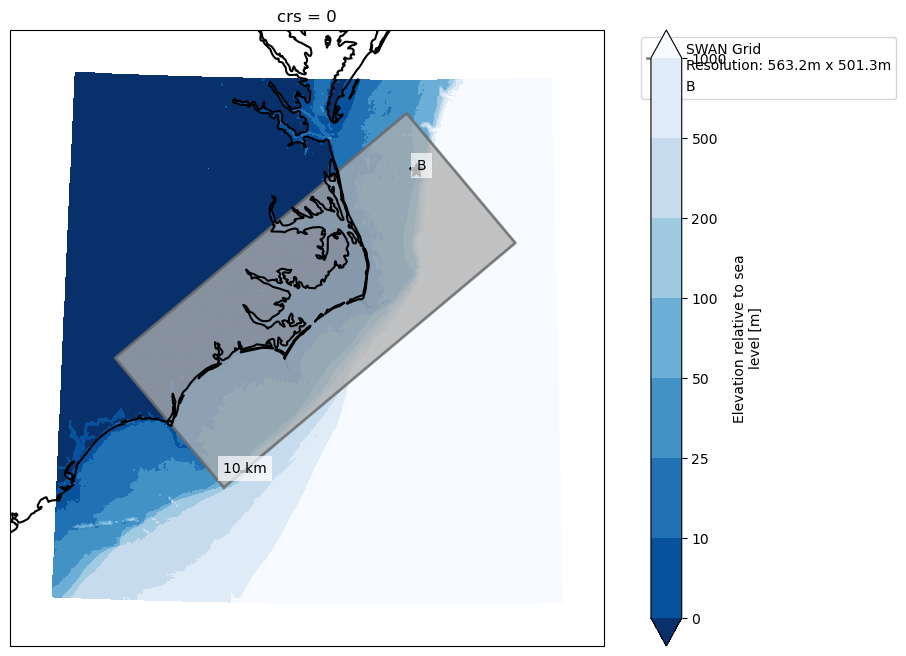

In [3]:
from utils.plotting import plot_bathy_swan_grid
import numpy as np
buoy_locations = np.array([514397.61, 4051843.74])
                          
plot_bathy_swan_grid(bathy=bathy, fixed_params=fixed_parameters_swan, utm_zone=18, plot_all_lines=True, points=buoy_locations, point_labels='Buoy 44088')

In [4]:
from scipy.interpolate import griddata

# Rest of the code...
x, y = 514397.61, 4051843.74

# Find nearest points
x_idx = np.abs(bathy.lon.values - x).argmin()
y_idx = np.abs(bathy.lat.values - y).argmin()

# Get the depth at the nearest point
depth = float(bathy[y_idx, x_idx])

print(f'Depth at point ({x}, {y}): {depth:.2f} meters')

# # For more accuracy, let's also do interpolation
# X, Y = np.meshgrid(bathy.lon.values, bathy.lat.values)
# points = np.column_stack((X.flatten(), Y.flatten()))
# values = bathy.values.flatten()
# interp_depth = float(griddata(points, values, [(x, y)], method='linear')[0])

# print(f'Interpolated depth: {interp_depth:.2f} meters')

# # Print some context about the location
# print(f'\nNearest grid coordinates:')
# print(f'X: {bathy.lon.values[x_idx]:.2f}')
# print(f'Y: {bathy.lat.values[y_idx]:.2f}')

Depth at point (514397.61, 4051843.74): 45.00 meters


In [5]:
import xarray as xr
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from utils.crop_bathy import plot_bathymetry, crop_bathy_to_grid

# Create outputs directory if it doesn't exist
Path("outputs").mkdir(exist_ok=True)

# Parameters
name = 'north_carolina'
resolution = 500  # meters

# Grid parameters
grid_params = fixed_parameters_swan    


# Print area extent
x_extent = float(bathy.lon.max() - bathy.lon.min()) / 1000  # km
y_extent = float(bathy.lat.max() - bathy.lat.min()) / 1000  # km
print(f'Area extent: {x_extent:.2f} km x {y_extent:.2f} km')

# Plot full domain with grid overlay
print("\nPlotting full domain with grid overlay...")
fig, ax, (x_coords, y_coords) = plot_bathymetry(
    bathy,
    grid_params=grid_params,
    min_z=0,
    max_z=500
)

# Save full domain plot
fig.savefig('outputs/full_domain.png', dpi=300, bbox_inches='tight')
plt.close(fig)

# Crop bathymetry around grid
print("\nCropping bathymetry around grid...")
buffer_distance = 10000  # 10 km buffer
cropped_bathy = crop_bathy_to_grid(bathy, grid_params, buffer_distance)

# Plot cropped domain
print("\nPlotting cropped domain...")
fig, ax, _ = plot_bathymetry(
    cropped_bathy,
    grid_params=grid_params,
    min_z=0,
    max_z=500
)

# Save cropped domain plot
fig.savefig('common_inputs/cropped_domain.png', dpi=300, bbox_inches='tight')
plt.close(fig)

# Save cropped bathymetry
output_file = f"common_inputs/bathy_{name}_rotated.nc"
print(f"\nSaving cropped bathymetry to {output_file}")
cropped_bathy.to_netcdf(output_file)

print("\nDone!")

Area extent: 603.03 km x 628.54 km

Plotting full domain with grid overlay...

Cropping bathymetry around grid...
Cropping bounds: x=[149077.20806269214, 642354.72940354], y=[3666471.67, 4128934.982982738]

Plotting cropped domain...

Saving cropped bathymetry to outputs/bathy_north_carolina_500m.nc

Done!


In [6]:
bathy=cropped_bathy
# Rest of the code...
x, y = 514397.61, 4051843.74

# Find nearest points
x_idx = np.abs(bathy.lon.values - x).argmin()
y_idx = np.abs(bathy.lat.values - y).argmin()

# Get the depth at the nearest point
depth = float(bathy[y_idx, x_idx])

print(f'Depth at point ({x}, {y}): {depth:.2f} meters')

Depth at point (514397.61, 4051843.74): 45.00 meters


## Create SWAN cases

In [7]:
fixed_parameters_bathy = {"xpinp": np.nanmin(bathy.lon),  # x origin
        "ypinp": np.nanmin(bathy.lat),  # y origin
        "alpinp": 0,  # x-axis direction
        "mxinp": len(bathy.lon) - 1,  # number mesh x
        "myinp": len(bathy.lat) - 1,  # number mesh y
        "dxinp": abs(
            bathy.lon[1].values - bathy.lon[0].values
        ),  # size mesh x (resolution in x)
        "dyinp": abs(
            bathy.lat[1].values - bathy.lat[0].values
        ),  # size mesh y (resolution in y)
        }
fixed_parameters_bathy 

{'xpinp': np.float64(149145.12296888902),
 'ypinp': np.float64(3666554.4198390255),
 'alpinp': 0,
 'mxinp': 1179,
 'myinp': 1105,
 'dxinp': np.float64(418.1894958758494),
 'dyinp': np.float64(418.1894958759658)}

In [8]:
fixed_parameters = { **fixed_parameters_swan, **fixed_parameters_bathy}
fixed_parameters

{'xpc': 287634.73,
 'ypc': 3676471.67,
 'alpc': 40,
 'xlenc': 450000,
 'ylenc': 200000,
 'mxc': 799,
 'myc': 399,
 'xpinp': np.float64(149145.12296888902),
 'ypinp': np.float64(3666554.4198390255),
 'alpinp': 0,
 'mxinp': 1179,
 'myinp': 1105,
 'dxinp': np.float64(418.1894958758494),
 'dyinp': np.float64(418.1894958759658)}

In [9]:
from bluemath_tk.waves.binwaves import generate_swan_cases
from utils.wrapper import example_directions, example_frequencies

# Generate swan model parameters
example_directions = example_directions
swan_cases_df = (
    generate_swan_cases(
        directions_array=example_directions,
        frequencies_array=example_frequencies,
    )
    .astype(float)
    .to_dataframe()
    .reset_index()
)
swan_cases_df

,dir,freq,hs,tp,spr,gamma
0,7.5,0.035000,1.0,28.5714,2.0,50.0
1,7.5,0.038500,1.0,25.9740,2.0,50.0
2,7.5,0.042350,1.0,23.6128,2.0,50.0
3,7.5,0.046585,1.0,21.4661,2.0,50.0
4,7.5,0.051243,1.0,19.5147,2.0,50.0
...,...,...,...,...,...,...
691,352.5,0.344741,0.1,2.9007,2.0,50.0
692,352.5,0.379215,0.1,2.6370,2.0,50.0
693,352.5,0.417136,0.1,2.3973,2.0,50.0
694,352.5,0.458850,0.1,2.1794,2.0,50.0


In [ ]:
import numpy as np
from bluemath_tk.waves.binwaves import plot_selected_cases_grid

# Plot the cases grid

plot_selected_cases_grid(
    frequencies=np.array(example_frequencies),
    directions=np.array(example_directions),
    figsize=(8, 8),
)

## Build and run SWAN cases

In [10]:
import os
from utils.wrapper import BinWavesWrapper

# Define the input templates and output directory for the wrapper

templates_dir = os.path.join(os.getcwd(), "templates")
templates_name = ["INPUT"]
output_dir = os.path.join(os.getcwd(), "NC_SC")

# Create an instance of the SWAN model wrapper

swan_wrapper = BinWavesWrapper(
    templates_dir=templates_dir,
    templates_name=templates_name,
    metamodel_parameters=swan_cases_df.to_dict(orient="list"),
    fixed_parameters=fixed_parameters,
    output_dir=output_dir,
    depth_dataarray=bathy,
)

Original depth_dataarray shape: (1106, 1180)
Grid points shape: (3731, 2)
Number of grid locations: 3731
Number of buoy locations: 7


2025-05-29 20:37:41,507 - BinWavesWrapper - WARNING - Parameter dir is not in the default_parameters
2025-05-29 20:37:41,508 - BinWavesWrapper - WARNING - Parameter freq is not in the default_parameters
2025-05-29 20:37:41,508 - BinWavesWrapper - WARNING - Parameter hs is not in the default_parameters
2025-05-29 20:37:41,508 - BinWavesWrapper - WARNING - Parameter tp is not in the default_parameters
2025-05-29 20:37:41,509 - BinWavesWrapper - WARNING - Parameter spr is not in the default_parameters
2025-05-29 20:37:41,509 - BinWavesWrapper - WARNING - Parameter gamma is not in the default_parameters


In [11]:
# Build the input files

# swan_wrapper.build_cases(mode="one_by_one")
# swan_cases_df.to_csv(os.path.join(output_dir, "swan_cases.csv"), index=False)

# Set the cases directories from the output directory
# Execute if the cases are already built

swan_wrapper.set_cases_dirs_from_output_dir()

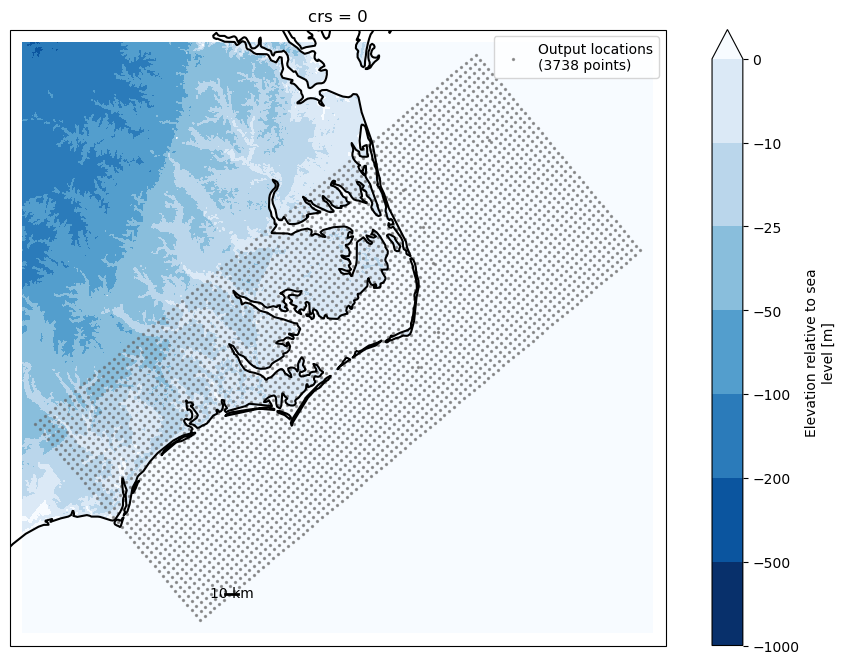

(<Figure size 1200x800 with 2 Axes>,
 <GeoAxes: title={'center': 'crs = 0'}, xlabel='x coordinate of projection\n[metre]', ylabel='y coordinate of projection\n[metre]'>)

In [12]:
from utils.plotting import plot_bathy_with_locations
plot_bathy_with_locations(
    bathy=bathy,
    locations_file="/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_SC/0000/locations.loc"
)

In [ ]:
# import numpy as np
# from pyproj import Transformer
# from utils.mesh_to_geojson import mesh_to_geojson

# import os

# # Read the coordinates from the file
# coords = np.loadtxt('/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/rotated_cases/0000/locations.loc')

# # Create transformer from UTM to WGS84
# utm_to_wgs84 = Transformer.from_crs("EPSG:32618", "EPSG:4326", always_xy=True)

# # Convert UTM coordinates to WGS84
# lons, lats = utm_to_wgs84.transform(coords[:, 0], coords[:, 1])

# # Convert to GeoJSON
# output_file = '/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/rotated_cases/0000/locations_rotated.geojson'

# try:
#     mesh_to_geojson(lons, lats, output_file)
#     print(f"File created at: {output_file}")
#     print(f"File exists: {os.path.exists(output_file)}")
#     print(f"File size: {os.path.getsize(output_file)} bytes")
# except Exception as e:
#     print(f"Error creating file: {e}")

In [13]:
# Run the model

swan_wrapper.run_cases_in_background(launcher="/software/geocean/swan/swan_serial.exe", num_workers=15)

In [1]:
import pandas as pd
pd.set_option('display.max_rows', None)  # Show all rows
swan_wrapper.monitor_cases()

NameError: name 'swan_wrapper' is not defined

In [ ]:
# # Monitor running cases

# swan_wrapper.monitor_cases()

In [36]:
# Post-process the output files

cases_bulk_parameters = swan_wrapper.postprocess_cases()
cases_bulk_parameters

2025-05-29 23:15:47,383 - BinWavesWrapper - ERROR - Output not postprocessed for case 1. Error: [Errno 2] No such file or directory: '/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_SC/0001/output.mat'.
2025-05-29 23:15:48,833 - BinWavesWrapper - ERROR - Output not postprocessed for case 258. Error: [Errno 2] No such file or directory: '/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_SC/0258/output.mat'.
2025-05-29 23:15:51,430 - BinWavesWrapper - ERROR - Output not postprocessed for case 666. Error: [Errno 2] No such file or directory: '/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_SC/0666/output.mat'.


<xarray.Dataset> Size: 3GB
Dimensions:   (case_num: 693, Yp: 400, Xp: 800)
Coordinates:
  * Xp        (Xp) float32 3kB 2.876e+05 2.881e+05 ... 6.319e+05 6.324e+05
  * Yp        (Yp) float32 2kB 3.676e+06 3.677e+06 ... 3.829e+06 3.83e+06
  * case_num  (case_num) int64 6kB 0 2 3 4 5 6 7 ... 689 690 691 692 693 694 695
Data variables:
    Hsig      (case_num, Yp, Xp) float32 887MB 0.0004246 0.0004409 ... 0.1219
    Tm02      (case_num, Yp, Xp) float32 887MB 28.44 28.45 28.45 ... 1.212 1.212
    Dir       (case_num, Yp, Xp) float32 887MB 33.79 33.06 32.33 ... 352.5 352.5

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/bluemath_tk/core/operations.py:342: RuntimeWarning: invalid value encountered in multiply
  x_rad = x_deg * np.pi / 180
/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/matplotlib/colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


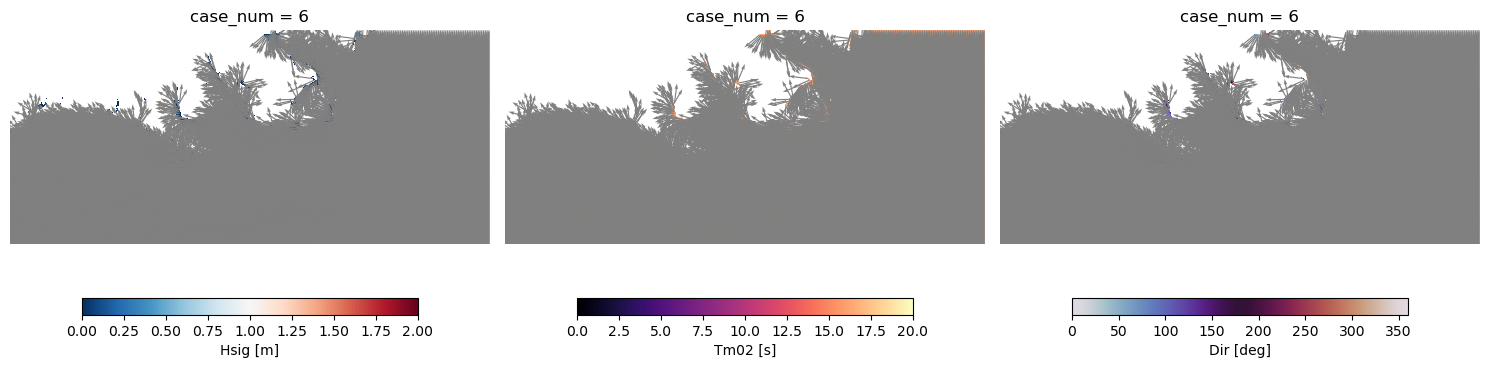

In [37]:
from utils.plotting import plot_case_variables

plot_case_variables(
    data=cases_bulk_parameters.isel(case_num=5),
)

## Plot ALL pre-run cases

"not all values found in index 'case_num'. Try setting the `method` keyword argument (example: method='nearest')."
"not all values found in index 'case_num'. Try setting the `method` keyword argument (example: method='nearest')."
"not all values found in index 'case_num'. Try setting the `method` keyword argument (example: method='nearest')."


/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/matplotlib/colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


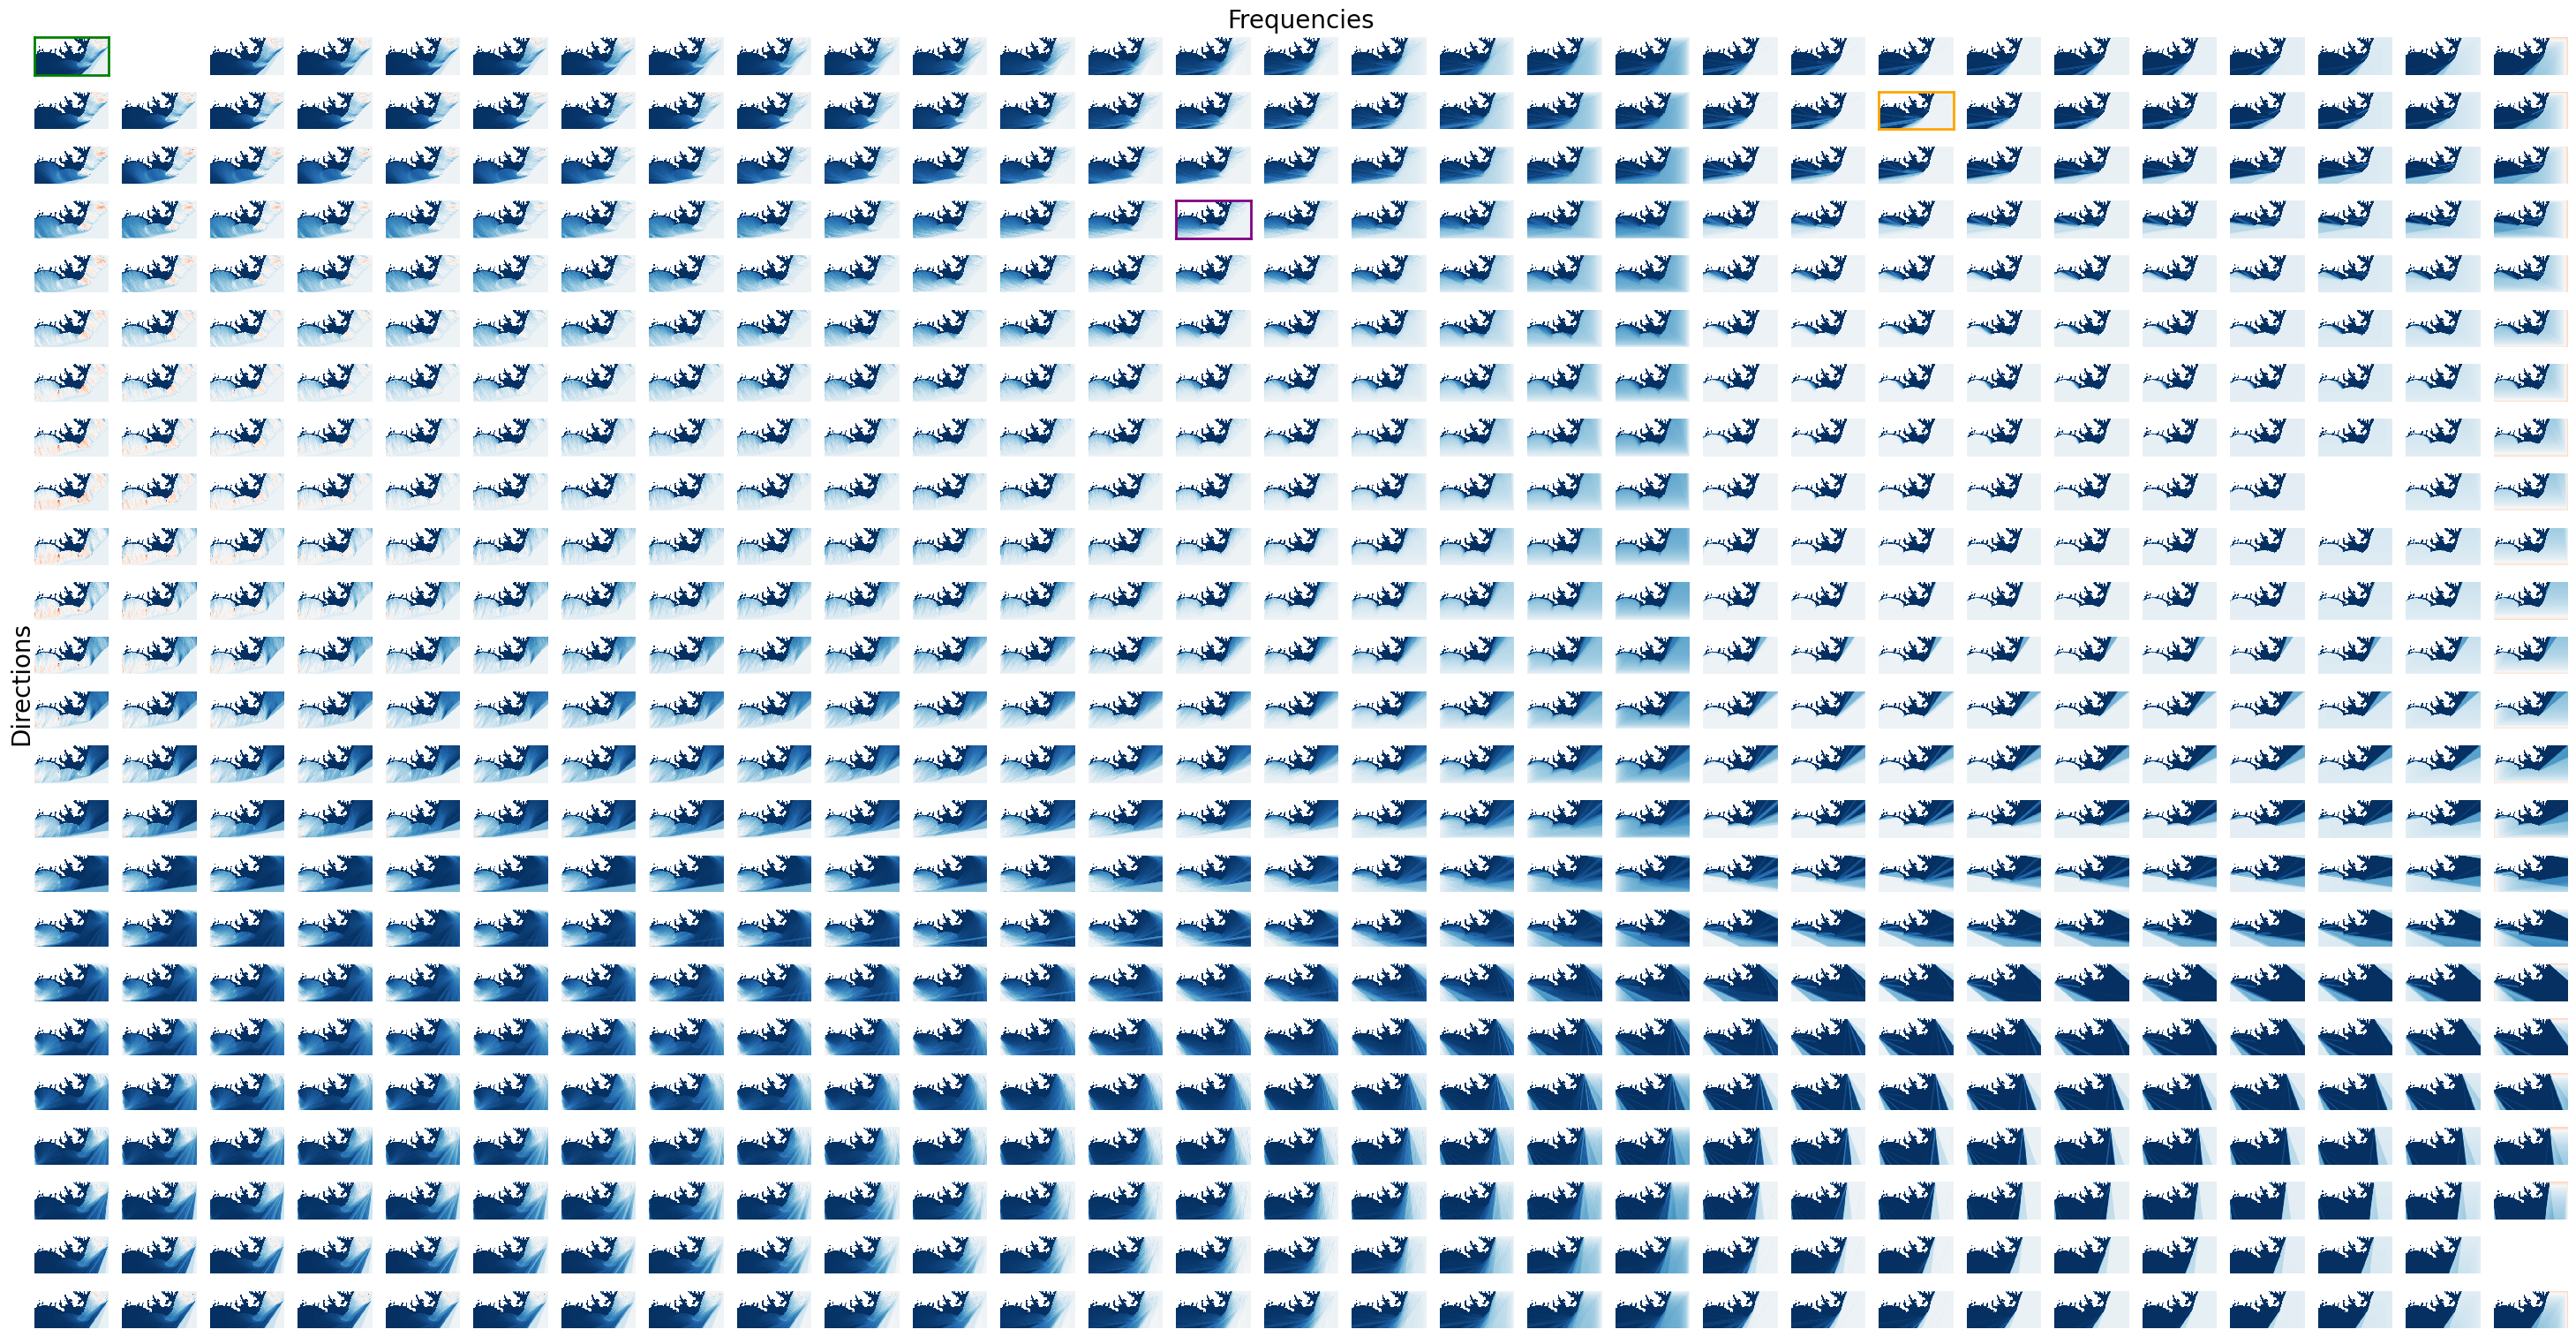

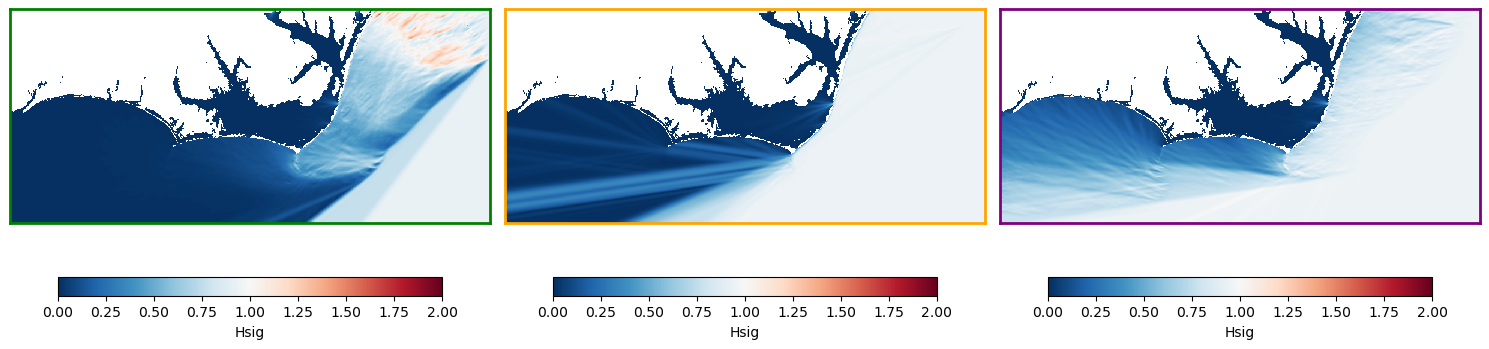

In [38]:
from utils.plotting import plot_cases_grid

plot_cases_grid(
    data=cases_bulk_parameters.Hsig.where(
        cases_bulk_parameters.case_num.isin(
            swan_cases_df.where(swan_cases_df["hs"] == 1.0).dropna().index.values
        ),
        cases_bulk_parameters.Hsig * 10,
    ),
    cases_to_plot=[0, 50, 100],
    num_directions=len(example_directions),
    num_frequencies=len(example_frequencies),
)

## Extract kp coefficients

In [13]:
# ps aux | grep python
# pkill -f "python"

In [39]:
from bluemath_tk.waves.binwaves import process_kp_coefficients

list_of_input_spectra = [
    os.path.join(case_dir, "input_spectra_N.bnd")
    for case_dir in swan_wrapper.cases_dirs
]
list_of_output_spectra = [
    os.path.join(case_dir, "output.spec") for case_dir in swan_wrapper.cases_dirs
]

kp_coefficients = process_kp_coefficients(
    list_of_input_spectra=list_of_input_spectra,
    list_of_output_spectra=list_of_output_spectra,
)
kp_coefficients

Error processing /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_SC/0001/input_spectra_N.bnd and /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_SC/0001/output.spec
[Errno 2] No such file or directory: '/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_SC/0001/output.spec'
Error processing /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_SC/0258/input_spectra_N.bnd and /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_SC/0258/output.spec
[Errno 2] No such file or directory: '/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_SC/0258/output.spec'


<xarray.DataArray 'efth' (case_num: 694, site: 3738, freq: 31, dir: 24)> Size: 15GB
array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [8.32667388e-12, 4.41313716e-08, 3.29653019e-08, ...,
          8.32667388e-12, 2.49800216e-11, 1.74860151e-10],
         [8.32667388e-12, 8.24423981e-08, 6.10928062e-08, ...,
          2.49800216e-11, 4.16333694e-11, 3.08086933e-10],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [3.37342625e-11, 1.65573894e-08, 1.46621372e-08, ...,
          3.06675113e-12, 0.00000000e+00, 2.26939584e-10],
         [5.21347693e-11, 3.03639030e-08, 2.81742427e-08, ...,
          3.06675113e-12, 3.06675113e-12, 3.89477394e-10],
...
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          1.64225056e-05, 8.72199274e-02, 1.62599228e-01]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [4.87037249e-05, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 3.05199734e-03]]]],
      shape=(694, 3738, 31, 24))
Coordinates:
  * case_num  (case_num) int64 6kB 0 2 3 4 5 6 7 ... 689 690 691 692 693 694 695
  * site      (site) int64 30kB 1 2 3 4 5 6 7 ... 3733 3734 3735 3736 3737 3738
  * freq      (freq) float64 248B 0.03 0.0329 0.0362 ... 0.4145 0.4552 0.5
  * dir       (dir) float64 192B 12.5 27.5 42.5 57.5 ... 312.5 327.5 342.5 357.5
    time      (case_num) datetime64[ns] 6kB 2025-05-29T23:19:00 ... 2025-05-2...
    lat       float64 8B 0.0
    lon       float64 8B 0.0

In [40]:
# kp_coefficients.to_dataset(name="kps").drop(["time", "lat", "lon"]).assign_coords(
#     utm_x=(("site"), swan_wrapper.locations[:, 0]),
#     utm_y=(("site"), swan_wrapper.locations[:, 1]),
# ).to_netcdf("outputs/kp_coefficients.nc")
# If you only need to drop 'time':
kp_coefficients.to_dataset(name="kps").drop(["time"]).assign_coords(
    utm_x=(("site"), swan_wrapper.locations[:, 0]),
    utm_y=(("site"), swan_wrapper.locations[:, 1]),
).to_netcdf("outputs_NC_SC/kp_coefficients.nc")

/tmp/ipykernel_2421715/2543329723.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  kp_coefficients.to_dataset(name="kps").drop(["time"]).assign_coords(


In [41]:
import numpy as np
import json
from pyproj import Transformer

def mesh_to_geojson(locations_x, locations_y, output_file):
    """
    Convert mesh coordinates to GeoJSON format.
    
    Args:
        locations_x: 2D array of longitude coordinates (WGS84)
        locations_y: 2D array of latitude coordinates (WGS84)
        output_file: Path to output GeoJSON file
    """
    features = []
    
    # Flatten the mesh and create features
    for i, (lon, lat) in enumerate(zip(locations_x.flatten(), locations_y.flatten())):
        feature = {
            "type": "Feature",
            "properties": {
                "id": f"{i:04d}",  # Format ID as 4-digit string
                "type": "BinWaves"
            },
            "geometry": {
                "type": "Point",
                "coordinates": [float(lon), float(lat)]
            }
        }
        features.append(feature)
    
    # Create the GeoJSON structure
    geojson = {
        "type": "FeatureCollection",
        "features": features
    }
    
    # Write to file
    with open(output_file, 'w') as f:
        json.dump(geojson, f, indent=2)

if __name__ == "__main__":
    # Create transformers for coordinate conversion
    wgs84_to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32618", always_xy=True)
    utm_to_wgs84 = Transformer.from_crs("EPSG:32618", "EPSG:4326", always_xy=True)
    
    # Define WGS84 coordinate ranges (longitude, latitude in degrees)
    lon_min, lon_max = -76.4, -74.4  # longitude range
    lat_min, lat_max = 34.8, 36.8   # latitude range
    
    # Convert WGS84 ranges to UTM for mesh creation
    utm_x_min, utm_y_min = wgs84_to_utm.transform(lon_min, lat_min)
    utm_x_max, utm_y_max = wgs84_to_utm.transform(lon_max, lat_max)
    
    # Calculate number of points for desired spacing
    spacing = 500  # meters
    step = 10      # take every Nth point
    
    # Calculate total number of points needed for the spacing
    n_x_total = int((utm_x_max - utm_x_min) / spacing) + 1
    n_y_total = int((utm_y_max - utm_y_min) / spacing) + 1
    
    # Calculate number of points after applying step
    n_x = n_x_total // step
    n_y = n_y_total // step
    
    # Create mesh in UTM coordinates with step
    utm_x = np.linspace(utm_x_min, utm_x_max, n_x_total)[::step]
    utm_y = np.linspace(utm_y_min, utm_y_max, n_y_total)[::step]
    utm_x_mesh, utm_y_mesh = np.meshgrid(utm_x, utm_y)
    
    # Convert UTM mesh back to WGS84
    lon_mesh = np.zeros_like(utm_x_mesh)
    lat_mesh = np.zeros_like(utm_y_mesh)
    
    for i in range(utm_x_mesh.shape[0]):
        for j in range(utm_x_mesh.shape[1]):
            lon_mesh[i,j], lat_mesh[i,j] = utm_to_wgs84.transform(utm_x_mesh[i,j], utm_y_mesh[i,j])
    
    # Convert to GeoJSON
    output_file = "mesh_points.geojson"
    mesh_to_geojson(lon_mesh, lat_mesh, output_file)
    print(f"Created GeoJSON file: {output_file}")
    print(f"Created mesh with {n_x}x{n_y} points (total: {n_x*n_y} points)")
    print(f"Original spacing: {spacing}m")
    print(f"Taking every {step}th point")
    print(f"Effective spacing: {spacing * step}m")
    print(f"WGS84 range: Lon({lon_min}, {lon_max}), Lat({lat_min}, {lat_max})")
    print(f"UTM range: X({utm_x_min:.2f}, {utm_x_max:.2f}), Y({utm_y_min:.2f}, {utm_y_max:.2f})")

Created GeoJSON file: mesh_points.geojson
Created mesh with 36x44 points (total: 1584 points)
Original spacing: 500m
Taking every 10th point
Effective spacing: 5000m
WGS84 range: Lon(-76.4, -74.4), Lat(34.8, 36.8)
UTM range: X(371933.14, 553525.42), Y(3851757.25, 4072853.98)


In [ ]:
import numpy as np
import json
from pyproj import Transformer

def mesh_to_geojson(locations_x, locations_y, output_file):
    """
    Convert mesh coordinates to GeoJSON format.
    
    Args:
        locations_x: 2D array of longitude coordinates (WGS84)
        locations_y: 2D array of latitude coordinates (WGS84)
        output_file: Path to output GeoJSON file
    """
    features = []
    
    # Flatten the mesh and create features
    for i, (lon, lat) in enumerate(zip(locations_x.flatten(), locations_y.flatten())):
        feature = {
            "type": "Feature",
            "properties": {
                "id": f"{i:04d}",  # Format ID as 4-digit string
                "type": "BinWaves"
            },
            "geometry": {
                "type": "Point",
                "coordinates": [float(lon), float(lat)]
            }
        }
        features.append(feature)
    
    # Create the GeoJSON structure
    geojson = {
        "type": "FeatureCollection",
        "features": features
    }
    
    # Write to file
    with open(output_file, 'w') as f:
        json.dump(geojson, f, indent=2)

if __name__ == "__main__":
    # Create transformers for coordinate conversion
    wgs84_to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32618", always_xy=True)
    utm_to_wgs84 = Transformer.from_crs("EPSG:32618", "EPSG:4326", always_xy=True)
    
    # Your WGS84 coordinates
    lon_min, lon_max = -76.4, -74.4  # longitude range
    lat_min, lat_max = 34.8, 36.8    # latitude range
    
    # Convert WGS84 to UTM
    utm_x_min, utm_y_min = wgs84_to_utm.transform(lon_min, lat_min)
    utm_x_max, utm_y_max = wgs84_to_utm.transform(lon_max, lat_max)
    
    # Round to nearest meter
    utm_x_min = int(utm_x_min)
    utm_x_max = int(utm_x_max)
    utm_y_min = int(utm_y_min)
    utm_y_max = int(utm_y_max)
    
    # Create arrays with step=10 like in the wrapper
    utm_x = np.arange(utm_x_min, utm_x_max + 1, 10)
    utm_y = np.arange(utm_y_min, utm_y_max + 1, 10)
    
    # Create the mesh in UTM coordinates
    utm_x_mesh, utm_y_mesh = np.meshgrid(utm_x, utm_y)
    
    # Convert UTM mesh back to WGS84
    lon_mesh = np.zeros_like(utm_x_mesh)
    lat_mesh = np.zeros_like(utm_y_mesh)
    
    for i in range(utm_x_mesh.shape[0]):
        for j in range(utm_x_mesh.shape[1]):
            lon_mesh[i,j], lat_mesh[i,j] = utm_to_wgs84.transform(utm_x_mesh[i,j], utm_y_mesh[i,j])
    
    # Convert to GeoJSON
    output_file = "mesh_points.geojson"
    mesh_to_geojson(lon_mesh, lat_mesh, output_file)
    print(f"Created GeoJSON file: {output_file}")
    print(f"Created mesh with {len(utm_x)}x{len(utm_y)} points (total: {len(utm_x)*len(utm_y)} points)")
    print(f"WGS84 input range: Lon({lon_min}, {lon_max}), Lat({lat_min}, {lat_max})")
    print(f"UTM range: X({utm_x_min}, {utm_x_max}), Y({utm_y_min}, {utm_y_max})")
    print(f"WGS84 output range: Lon({lon_mesh.min():.6f}, {lon_mesh.max():.6f}), Lat({lat_mesh.min():.6f}, {lat_mesh.max():.6f})")
    print(f"Step size: 10 meters")